# V_1.0.2

In [ ]:
# Import libraries and set up file paths
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Set the single Root ML folder relative to this notebook
ML = Path("..") 

# 2. Load the Master Dataset using the Root path
print("Loading Master Dataset...")
master_df = pd.read_parquet(ML / 'dataset/processed/master_dataset.parquet')

# 3. Display basic information
print(f"\nDataset Shape: {master_df.shape[0]} patients, {master_df.shape[1]} columns")

print("\n--- FIRST 3 RAW CHIEF COMPLAINTS ---")
# Show the first 3 actual sentences the nurses typed to make sure we have them
for i, sentence in enumerate(master_df['chief_complaint_raw'].head(3)):
    print(f"Patient {i+1}: \"{sentence}\"")


In [ ]:
nlp_parquet_path = ML / 'dataset/processed/nlp_ready_dataset.parquet'

if not nlp_parquet_path.exists():
    print("Cleaning data and repairing text fields...")
    
    # 1. Drop the 13 bad columns (KEEPING chief_complaint_raw!)
    columns_to_drop = [
        'patient_id', 'site_id', 'triage_nurse_id', 
        'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 
        'language', 'transport_origin', 'insurance_type', 
        'disposition', 'ed_los_hours'
    ]
    
    clean_df = master_df.drop(columns=columns_to_drop)

    # 2. Fix the Text so BioBERT doesn't crash
    #Catboost can handle empty values for numrical data itself.
    clean_df['chief_complaint_raw'] = clean_df['chief_complaint_raw'].fillna("No Data")
    categorical_cols = clean_df.select_dtypes(include=['object', 'string']).columns
    clean_df[categorical_cols] = clean_df[categorical_cols].fillna("Unknown")

    # 3. Save it securely to the processed folder
    clean_df.to_parquet(nlp_parquet_path, index=False)
    print(f"Success! NLP-ready dataset physically saved to: {nlp_parquet_path}")
    
else:
    print("NLP-ready dataset already exists!")
    clean_df = pd.read_parquet(nlp_parquet_path)

print(f"\nFinal Shape: {clean_df.shape[0]} patients, {clean_df.shape[1]} columns")


In [ ]:
# Translates English clinical text into 768-Dimensional mathematical arrays using the BioBERT Language Model.

import torch
import json
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

# 1. Load your v1.0.0 Configuration
with open("../params/v1.0.0.json", "r") as f:
    config = json.load(f)

model_name = config["BERT_MODEL_NAME"]
batch_size = config["BERT_BATCH_SIZE"]
max_len = config["BERT_MAX_LENGTH"]

# 2. Hardware Detection (PyTorch will find your GPU if it exists)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"BioBERT Engine powering up on: {device}")

# 3. Download the specific Medical BERT model
print(f"Loading Model: {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name).to(device)

# 4. Get the sentences ready
texts = clean_df['chief_complaint_raw'].tolist()
all_embeddings = []

# 5. Process the sentences! (We loop in batches so your computer's RAM doesn't explode)
print(f"\nTranslating {len(texts)} sentences into Math...")
bert_model.eval() 

with torch.no_grad(): # We are just using the model, not training it
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i : i + batch_size]
        
        # Tokenize (Convert English words to Token IDs)
        encoded = tokenizer(
            batch_texts, 
            padding=True, 
            truncation=True, 
            max_length=max_len, 
            return_tensors='pt'
        ).to(device)
        
        # Push the Tokens through the Neural Network
        outputs = bert_model(**encoded)
        
        # Extract the [CLS] token (BioBERT's mathematical summary of the whole sentence)
        batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(batch_embeddings)

# Combine the batches into one giant super-matrix
final_embeddings = np.vstack(all_embeddings)

print(f"\nBioBERT processing complete! Matrix shape: {final_embeddings.shape}")


In [ ]:
# Compresses the massive 768-D NLP matrix down to 10 dense dimensions (PCA) to prevent CatBoost from freezing or overfitting.

import joblib
from sklearn.decomposition import PCA

# 1. Look up the PCA compression level from your JSON config
n_components = config["PCA_COMPONENTS"]
print(f"Compressing 768 BioBERT dimensions down to {n_components}...")

# 2. Build the PCA Compressor (The ZIP file engine)
pca = PCA(n_components=n_components, random_state=42)

# 3. Mathematically squish the giant matrix!
compressed_embeddings = pca.fit_transform(final_embeddings)

print(f"Compression successful! New shape: {compressed_embeddings.shape}")

# 4. Turn the raw math matrix into nice Pandas columns (biobert_pca_1, biobert_pca_2, etc.)
pca_columns = [f"biobert_pca_{i+1}" for i in range(n_components)]
pca_df = pd.DataFrame(compressed_embeddings, columns=pca_columns)

# 5. Glue the 10 new math columns onto our original dataset!
# We cleanly delete the 'chief_complaint_raw' sentences because we don't need text anymore!
final_df = pd.concat([clean_df.drop(columns=['chief_complaint_raw']), pca_df], axis=1)

print(f"\nFinal AI Super-Matrix perfectly assembled!")
print(f"Total shape: {final_df.shape[0]} patients, {final_df.shape[1]} columns")

# 6. Save the mathematical PCA model to your hard drive
pca_path = ML / 'models/v1.0.2/pca_v1.0.2.pkl'
joblib.dump(pca, pca_path)
print(f"SUCCESS! The PCA Compressor was legally saved to: {pca_path}")

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

# 1. Setup Data & Config
with open(ML / "params/v1.0.2.json", "r") as f:
    config = json.load(f)

Y = final_df['triage_acuity']
X = final_df.drop(columns=['triage_acuity'])
cat_features = list(X.select_dtypes(include=['object', 'string']).columns)

# 2. Create the Vault System
cv_folds = config["CV_FOLDS"]
skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=config["RANDOM_SEED"])
out_of_fold_predictions = np.zeros(len(Y))

best_score = 0
best_fold = 0
last_model = None

# 3. The Grand Training Loop!
print(f"--- STARTING {cv_folds}-FOLD BIOBERT TRAINING ---")
for fold, (train_idx, test_idx) in enumerate(skf.split(X, Y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    Y_train, Y_test = Y.iloc[train_idx], Y.iloc[test_idx]
    
    # Train the Brain
    model = CatBoostClassifier(**config["CATBOOST_PARAMS"])
    model.fit(X_train, Y_train, cat_features=cat_features, eval_set=(X_test, Y_test))
    
    # Safely save guesses for the final report
    fold_preds = model.predict(X_test)
    out_of_fold_predictions[test_idx] = fold_preds.flatten()
    
    # Grade this specific brain
    score = accuracy_score(Y_test, fold_preds)
    print(f"Fold {fold + 1} Accuracy: {score * 100:.2f}%")
    
    # Save it to the Hard Drive
    model_path = ML / f"models/v1.0.2/model_v1.0.2_fold_{fold+1}.cbm"
    model.save_model(str(model_path))
    
    # Natively track the Champion! (No need to loop them again later)
    if score > best_score:
        best_score = score
        best_fold = fold + 1
        
    last_model = model # Keep this in RAM so we can draw the graph later

print("\n" + "="*50)
print(f"🏆 CHAMPION CROWNED: Fold {best_fold} with {best_score * 100:.2f}% accuracy!")
print(f"FINAL PIPELINE ACCURACY: {accuracy_score(Y, out_of_fold_predictions) * 100:.2f}%")
print("="*50)


In [8]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Production Metrics...")

# 1. Print and Save the Classification Report
report = classification_report(Y, out_of_fold_predictions)
print(report)

with open(ML / "metrics/v1.0.2/classification_report.txt", "w") as f:
    f.write(f"🏥 V1.0.2 PRODUCTION REPORT\nFinal Accuracy: {(accuracy_score(Y, out_of_fold_predictions) * 100):.2f}%\n\n{report}")

# 2. Extract Feature Importance
feature_importances = last_model.get_feature_importance(prettified=True)

# 3. Draw the Graph
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importances', y='Feature Id', hue='Feature Id', legend=False, 
    data=feature_importances.head(15), palette='viridis'
)
plt.title("Top 15 Most Crucial Clinical Indicators (BioBERT)", fontsize=16, fontweight='bold')
plt.xlabel("Mathematical Importance to CatBoost", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# 4. Legally save the Graph image to the Hard Drive
plt.savefig(ML / "metrics/v1.0.2/feature_importance.png", bbox_inches='tight', dpi=300)
plt.show()

print("✅ Success: MLOps records physically dumped to ml/metrics/")


Generating Production Metrics...


NameError: name 'Y' is not defined

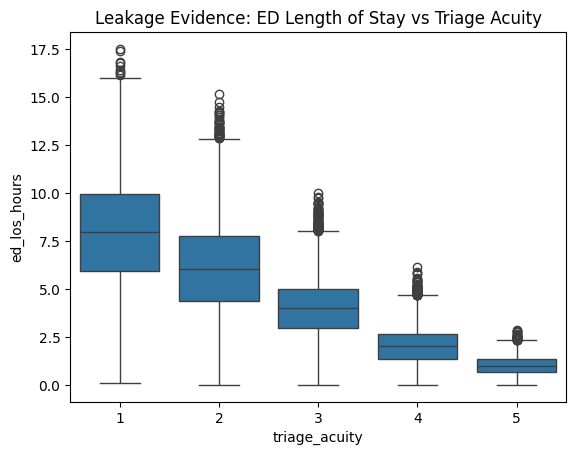

In [11]:
sns.boxplot(x='triage_acuity', y='ed_los_hours', data=master_df)
plt.title('Leakage Evidence: ED Length of Stay vs Triage Acuity')
plt.savefig(ML / "metrics/v1.0.2/leakage_evidence.png", bbox_inches='tight', dpi=300)

